In [71]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
avocado=pd.read_csv('avocado.csv')

In [72]:
avocado

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [73]:
a=avocado
a.isnull().sum()
#בדיקה אם אין ערכים ריקים בדטאט

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [74]:
#הוספת שורה לחודש- כלומר לקחת מעמודת תאריך את החודש ולא להשתמש בתאריך
a['month']=pd.to_datetime(a['Date']).dt.month

In [75]:
#קידוד
a=pd.get_dummies(a, columns=['type','region'],drop_first=True, dtype=int)

X=a.drop(['Unnamed: 0','Date','AveragePrice'],axis=1)
#נירמול
scaler_minmax =MinMaxScaler().set_output(transform="pandas")
X=scaler_minmax.fit_transform(X)


In [76]:
 #בדיקת בנירמול-לבדוק שהערכים בין 0 ל1
print(X.agg(['min','max']))

     Total Volume  4046  4225  4770  Total Bags  Small Bags  Large Bags  \
min           0.0   0.0   0.0   0.0         0.0         0.0         0.0   
max           1.0   1.0   1.0   1.0         1.0         1.0         1.0   

     XLarge Bags  year  month  ...  region_SouthCarolina  region_SouthCentral  \
min          0.0   0.0    0.0  ...                   0.0                  0.0   
max          1.0   1.0    1.0  ...                   1.0                  1.0   

     region_Southeast  region_Spokane  region_StLouis  region_Syracuse  \
min               0.0             0.0             0.0              0.0   
max               1.0             1.0             1.0              1.0   

     region_Tampa  region_TotalUS  region_West  region_WestTexNewMexico  
min           0.0             0.0          0.0                      0.0  
max           1.0             1.0          1.0                      1.0  

[2 rows x 64 columns]


In [77]:
best_k=[]
k_ =range(1,11)
for k in k_ :
    Kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    Kmeans.fit(X)
    best_k.append(Kmeans.inertia_)

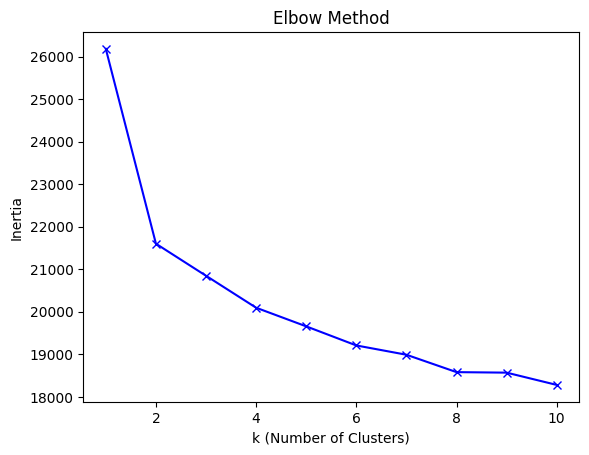

In [78]:
# ציור הגרף
plt.plot(k_, best_k, 'bx-')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Silhouette Score: 0.11


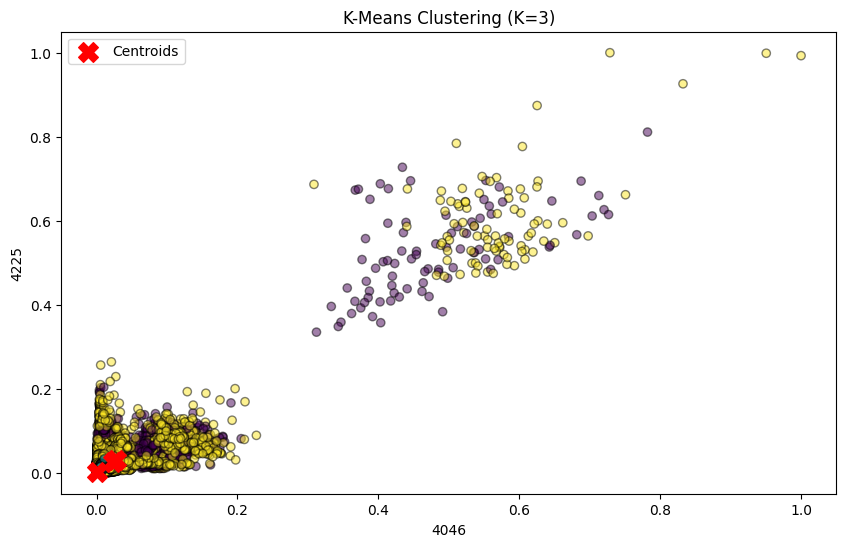

In [ ]:
#kmeans

# הפעלת המודל
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# הוספת התוצאות לדאטה המקורי כדי שנוכל לנתח אותן
a['Cluster'] = clusters

print(f"Silhouette Score: {silhouette_score(X, clusters):.2f}")

# ויזואליזציה מתוקנת (שימוש ב-iloc עבור DataFrame)
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[:, 1], X.iloc[:, 2], c=clusters, cmap='viridis', marker='o', edgecolor='k', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='red', marker='X', label='Centroids')

plt.title(f"K-Means Clustering (K={optimal_k})")
plt.xlabel(X.columns[1]) # שם העמודה הראשונה שמוצגת
plt.ylabel(X.columns[2]) # שם העמודה השנייה שמוצגת
plt.legend()
plt.show()

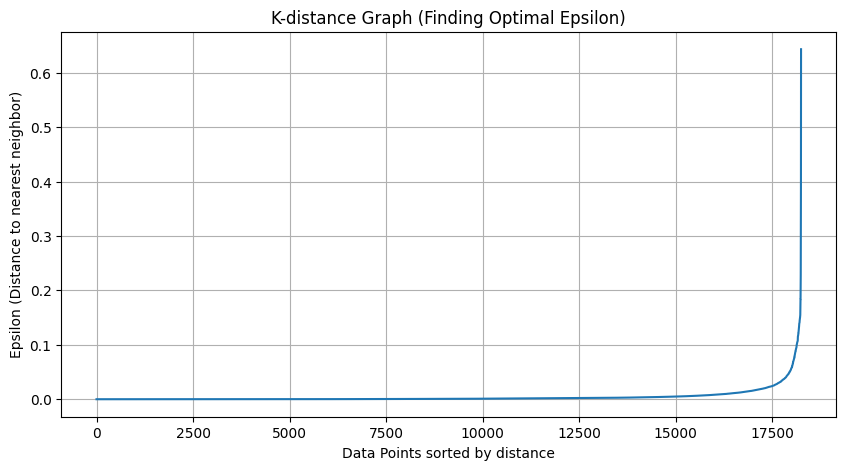

In [ ]:
#dbscan
#מציאת epsilon
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, 1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph (Finding Optimal Epsilon)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance to nearest neighbor)')
plt.grid(True)
plt.show()

In [85]:

dbscan = DBSCAN(eps=0.05, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

n_clusters_ = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise_ = list(clusters).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

Estimated number of clusters: 1280
Estimated number of noise points: 11849


Silhouette Coefficient: -0.230


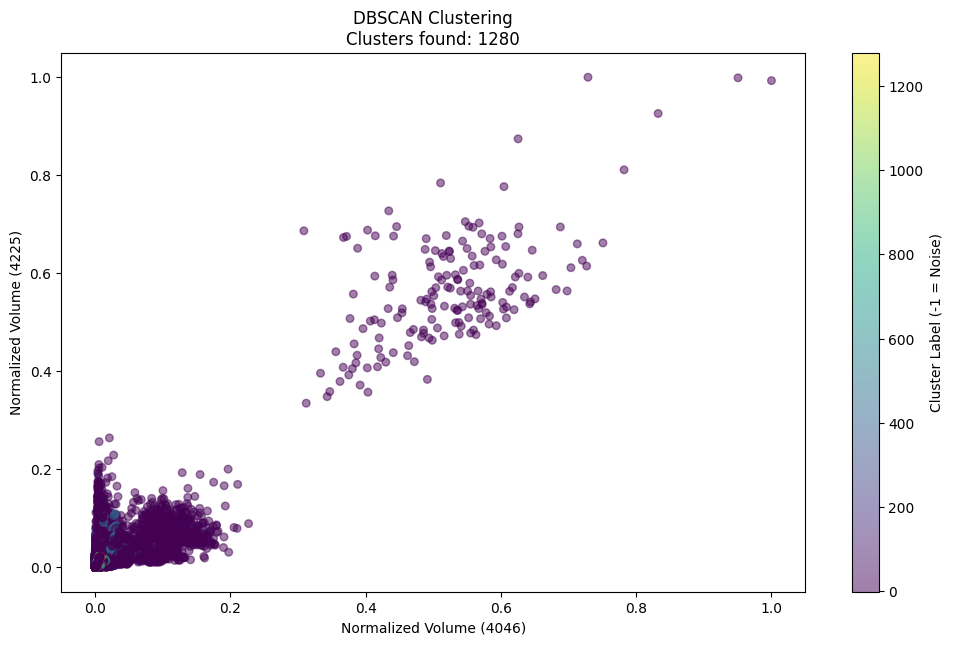

In [84]:
if n_clusters_ > 1:
    score = silhouette_score(X, clusters)
    print(f"Silhouette Coefficient: {score:.3f}")

plt.figure(figsize=(12, 7))
plt.scatter(X.iloc[:, 1], X.iloc[:, 2], c=clusters, cmap='viridis', alpha=0.5, s=30)
plt.colorbar(label='Cluster Label (-1 = Noise)')
plt.title(f'DBSCAN Clustering\nClusters found: {n_clusters_}')
plt.xlabel('Normalized Volume (4046)')
plt.ylabel('Normalized Volume (4225)')
plt.show()